# Customer Segmentation 

# Datasetni Yuklash 

In [2]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\Rasulbekk\Desktop\Practise\Data\marketing_campaign.csv", sep='\t')

print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

# Data Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
df = df[["Year_Birth", "Income", "Recency", "MntWines", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "NumDealsPurchases", "NumWebPurchases", "Response"]]

# missing values 
df = df.dropna()
print(df.isnull().sum())

Year_Birth           0
Income               0
Recency              0
MntWines             0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
NumDealsPurchases    0
NumWebPurchases      0
Response             0
dtype: int64


# Feature Enginering 

In [5]:
df["Age"] = 2026 - df["Year_Birth"]

df["Total_Spending"] = (df["MntWines"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"])

df = df.drop("Year_Birth", axis=1)

# Scaling bosqichi

In [6]:
from sklearn.preprocessing import StandardScaler

x = df.drop("Response", axis=1) 
y =df["Response"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# UNS ML qismi boshlandi Clustering uchun Optimal k qiyamtini topib olamiz 

In [7]:
# Elbow metodi yordamida topib olamiz 

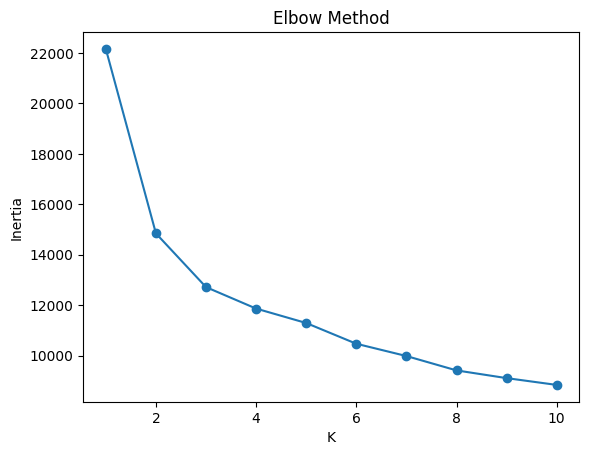

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 

inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker = 'o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
optimal_k = 4

# Clutering - Customer Segmentation 

In [10]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
df['cluster'] = clusters

In [11]:
df.head()

,Income,Recency,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,NumDealsPurchases,NumWebPurchases,Response,Age,Total_Spending,cluster
0,58138.0,58,635,546,172,88,3,8,1,69,1441,1
1,46344.0,38,11,6,2,1,2,1,0,72,20,0
2,71613.0,26,426,127,111,21,1,8,0,61,685,2
3,26646.0,26,11,20,10,3,2,2,0,42,44,0
4,58293.0,94,173,118,46,27,5,5,0,45,364,3


# Cluster -->  feature 

In [12]:
x_new = df.drop("Response", axis=1)
y = df["Response"]

# Train Test Split 

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

# SML model uchun training 

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)
model.fit(x_train, y_train)
print("Accuracy: ", model.score(x_test, y_test))

Accuracy:  0.8851351351351351


# Modelni saqlash 

In [15]:
import joblib 

joblib.dump(model, "marketing_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans.pkl")

['kmeans.pkl']

# Real Prediction pipeline 

In [20]:
model = joblib.load("marketing_model.pkl")
scaler = joblib.load("scaler.pkl")
kmeans = joblib.load("kmeans.pkl")

new_data = x.iloc[0:1]
new_scaled = scaler.transform(new_data)
cluster = kmeans.predict(new_scaled)
new_data['cluster'] = cluster
prediction = model.predict(new_data)

print("Will respond to campaign:", prediction)

Will respond to campaign: [1]


| Cluster | Tavsif          |
| ------- | --------------- |
| 0       | Low spender     |
| 1       | High income VIP |
| 2       | Discount lover  |
| 3       | Online buyer    |


# Recommend function (hybrid)

In [ ]:
le_input = LabelEncoder()
le_output = LabelEncoder()

ml_df['input_enc'] = le_input.fit_transform(ml_df['input_product']) 
ml_df["output_enc"] = le_output.fit_transform(ml_df['recommended_product'])

In [ ]:
model = joblib.load("marketing_model.pkl")
scaler = joblib.load("scaler.pkl")
kmeans = joblib.load("kmeans.pkl")


def recommend(product):
    product_enc = le_input.transform([product])[0]
    sample = [[product_enc, 0.5, 1.2]]
    pred = model.predict(sample)

    return le_output.inverse_transform(pred)